In [2]:
import anndata
import networkx as nx
import numpy as np
import scgenome.plotting as pl
import matplotlib.pyplot as plt

from cellmates.utils.math_utils import compute_cn_changes
from cellmates.utils.tree_utils import f1_score_clades, relabel_name_to_int, newick_to_nx, convert_networkx_to_dendropy, \
    nxtree_to_newick, normalized_rf_distance

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Analysis for SPECTRUM OV-110 dataset


## OV-110

In [3]:
path = "/home/vittorio.zampinetti/cellmates_res/real_data/SPECTRUM-OV-110_cm_out/processed_adata.h5ad"

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 56 × 598
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'index_i7', 'total_duplicate_reads', 'is_control', 'primer_i7', 'pick_met', 'index_i5', 'is_contaminated', 'percent_duplicate_reads', 'fastqscreen_total_reads', 'row', 'unpaired_mapped_reads', 'fastqscreen_mouse', 'fastqscreen_nohit', 'overlap_with_all_filters', 'unmapped_reads', 'overlap_with_all_filters_and_qual', 'overlap_without_dups', 'fastqscreen_human', 'column', 'expected', 'overlap_with_dups', 'condition', 'total_mapped_reads', 'index_sequence', 'library_id', '

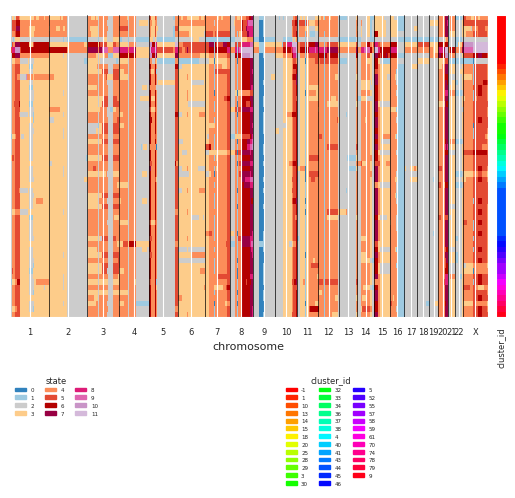

In [4]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

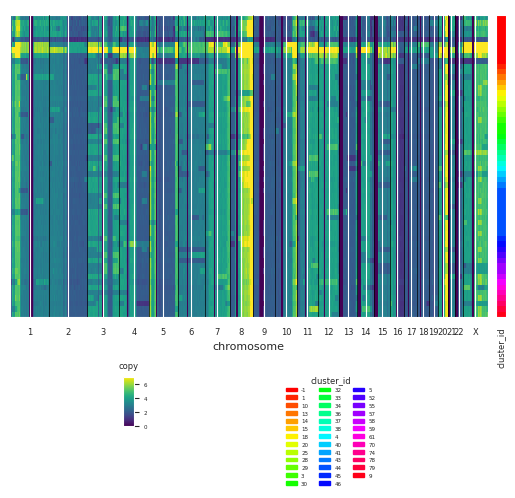

In [5]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

#### KMeans clustering

Keeping bins without nans: 598 / 598
Running KMeans with K=4
  Silhouette score: 0.5465
Running KMeans with K=5
  Silhouette score: 0.5610
Running KMeans with K=6
  Silhouette score: 0.3582
Running KMeans with K=7
  Silhouette score: 0.3588
Running KMeans with K=8
  Silhouette score: 0.0682
Running KMeans with K=9
  Silhouette score: 0.0642

Best K: 5 with silhouette score: 0.5610


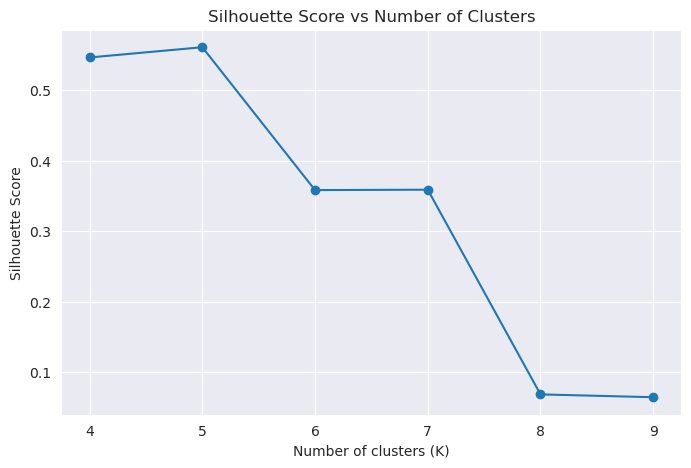

In [6]:
rerun_kmeans = True
if rerun_kmeans:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    kval = [4, 5, 6, 7, 8, 9]
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    print(f"Keeping bins without nans: {np.sum(valid_bins)} / {adata.n_vars}")
    cn_mat = adata[:, valid_bins].layers['state']

    silhouette_scores = []
    best_k = None
    best_score = -1
    best_labels = None

    for k in kval:
        print(f"Running KMeans with K={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(cn_mat)

        # Calculate silhouette score
        score = silhouette_score(cn_mat, labels)
        silhouette_scores.append(score)
        print(f"  Silhouette score: {score:.4f}")

        # Track best k
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\nBest K: {best_k} with silhouette score: {best_score:.4f}")

    # Optional: visualize results
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.plot(kval, silhouette_scores, marker='o')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.grid(True)
    plt.show()

    # Store best clustering in adata
    adata.obs[f'kmeans_k{best_k}'] = best_labels
else:
    print("Best K: 9 with silhouette score: 0.4477")

#### Leiden clustering


Running Leiden with resolution=1.0
  Clusters: 3
  Silhouette: 0.0075
  Davies-Bouldin: 2.3180 (lower is better)
  Calinski-Harabasz: 3.39 (higher is better)

Running Leiden with resolution=1.5
  Clusters: 11
  Silhouette: -0.2631
  Davies-Bouldin: 2.0588 (lower is better)
  Calinski-Harabasz: 1.58 (higher is better)

Running Leiden with resolution=2.0
  Clusters: 18
  Silhouette: -0.2125
  Davies-Bouldin: 1.6455 (lower is better)
  Calinski-Harabasz: 1.17 (higher is better)

=== Summary ===
   resolution  n_clusters  silhouette  davies_bouldin  calinski_harabasz
0         1.0           3    0.007493        2.317959           3.392774
1         1.5          11   -0.263114        2.058799           1.582613
2         2.0          18   -0.212459        1.645497           1.166187

Best by Silhouette: resolution=1.0, score=0.0075
Best by Davies-Bouldin: resolution=2.0, score=1.6455
Best by Calinski-Harabasz: resolution=1.0, score=3.39


/tmp/ipykernel_905962/1925022367.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')


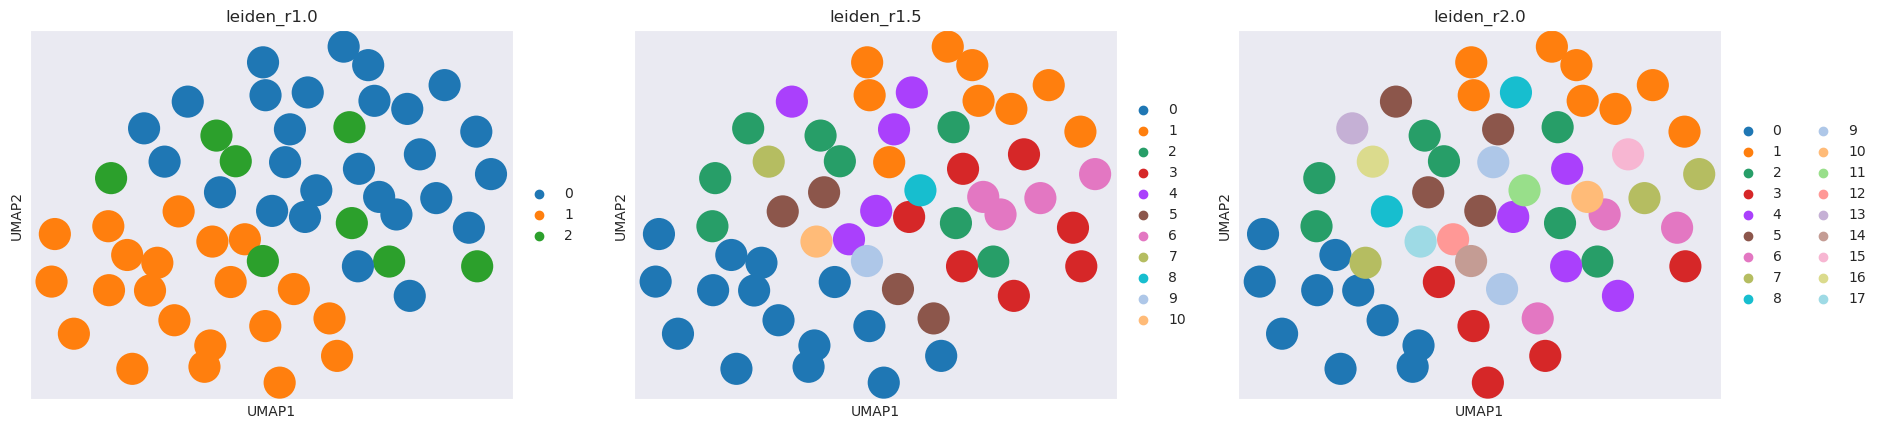

In [7]:
rerun_leiden = True
if rerun_leiden:
    import scanpy as sc
    import numpy as np

    # 1. First, compute neighbors on your CN state data (not the default adata.X)
    # Temporarily store filtered CN data in adata.X for neighbor computation
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    adata_filt = adata[:, valid_bins].copy()
    adata_filt.X = adata_filt.layers['state']

    # 2. Compute neighbors on the CN data
    sc.pp.neighbors(adata_filt, n_neighbors=15, n_pcs=0, metric='manhattan')  # n_pcs=0 means use raw data, no PCA

    # 3. Try different resolutions and evaluate with multiple metrics
    resolutions = [1.0, 1.5, 2.0]
    results = []

    for res in resolutions:
        print(f"\nRunning Leiden with resolution={res}")
        sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')

        labels = adata_filt.obs[f'leiden_r{res}'].astype('category').cat.codes.values
        n_clusters = len(np.unique(labels))

        # Calculate multiple metrics
        from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

        sil_score = silhouette_score(adata_filt.X, labels)
        db_score = davies_bouldin_score(adata_filt.X, labels)  # Lower is better
        ch_score = calinski_harabasz_score(adata_filt.X, labels)  # Higher is better

        adata.obs[f'leiden_r{res}'] = labels

        results.append({
            'resolution': res,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score
        })

        print(f"  Clusters: {n_clusters}")
        print(f"  Silhouette: {sil_score:.4f}")
        print(f"  Davies-Bouldin: {db_score:.4f} (lower is better)")
        print(f"  Calinski-Harabasz: {ch_score:.2f} (higher is better)")


    # 5. Summary and best resolution selection
    import pandas as pd
    results_df = pd.DataFrame(results)
    print("\n=== Summary ===")
    print(results_df)

    # Best by different metrics
    best_sil = results_df.loc[results_df['silhouette'].idxmax()]
    best_db = results_df.loc[results_df['davies_bouldin'].idxmin()]
    best_ch = results_df.loc[results_df['calinski_harabasz'].idxmax()]

    print(f"\nBest by Silhouette: resolution={best_sil['resolution']}, score={best_sil['silhouette']:.4f}")
    print(f"Best by Davies-Bouldin: resolution={best_db['resolution']}, score={best_db['davies_bouldin']:.4f}")
    print(f"Best by Calinski-Harabasz: resolution={best_ch['resolution']}, score={best_ch['calinski_harabasz']:.2f}")
    # 6. Optional: Visualize if you have UMAP/PCA
    sc.tl.umap(adata_filt)
    sc.pl.umap(adata_filt, color=[f'leiden_r{r}' for r in [1.0, 1.5, 2.0]])#%% md
else:
    print("Not run yet")

#### Conclusions
Both clustering methods find very poor clustering, therefore we can conclude that this dataset, despite the motivation, is just trash (it doesn't suit our purposes)

### Cellmates tree

In [8]:
import os
import io
from Bio import Phylo

cm_out_dir = "/home/vittorio.zampinetti/cellmates_res/real_data/SPECTRUM-OV-110_cm_out"
cell_names = open(os.path.join(cm_out_dir, "cell_names.txt")).read().splitlines()
tree_nwk = open(os.path.join(cm_out_dir, "tree.nwk")).read().strip()
nx_tree = newick_to_nx(tree_nwk)
bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight='weight')), "newick")
# bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree)), "newick")
print(tree_nwk)
print(len(cell_names), adata[cell_names].n_obs)
print(cell_names, adata[cell_names].obs.index.tolist())

(SPECTRUM-OV-110_S1_BOWEL-130424A-R55-C47:0.007190399487565462,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R13-C44:0.006982122074743191,((SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R24-C22:0.006518178706465941,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R30-C25:0.008236962235330986,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R22-C50:0.004572484795023183,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R29-C15:0.003990294163832644,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R30-C50:0.004375271987662882,((SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R26-C62:0.004374712216322424,SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R28-C62:0.0033222480906093597)ancestor12:0.0013175492731673745,((SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R23-C17:0.0051780541017319515,SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R23-C59:0.00332525897004265)ancestor14:0.0010264534588835337,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-110720-R31-C22:0.0038020027062985943,(SPECTRUM-OV-110_S1_INFRACOLIC_OMENTUM-1107

In [9]:
# add cellmates cn
def get_cellmates_cn_matrix(pred_file="predicted_copy_numbers.npz"):
    prediction = np.load(os.path.join(cm_out_dir, pred_file))
    cn_mat = prediction['data']
    labels = prediction['labels']  # [cell0, cell1, ..., ancestor3, ..., root]
    cn_mat.shape
    map_cells = {l: i for i, l in enumerate(labels)}
    cell_cn_mat = cn_mat[[map_cells[c] for c in cell_names]]
    return cell_cn_mat


In [10]:
import pickle
diags = None
with open(cm_out_dir + "/em_diagnostics.pkl", "rb") as f:
    diags = pickle.load(f)
print(diags[(0, 1)])

tau_array = np.concatenate([diags[x]['psis'][-1][[1,3]] for x in diags.keys()])
print(f"tau stats: {tau_array.shape}, mean: {np.mean(tau_array):.4f} +- {np.std(tau_array):.4f}")

# for c, lab in enumerate(cell_names):


{'loglikelihoods': [None, -997.5923484132866, -820.6446965967592, -797.8943441233753, -797.0761618467494, -797.4653934849385, -797.6266028743248, -797.6791032134729, -797.6937555567921, -797.6957209431407, -797.6944971167632], 'thetas': [array([0.00914855, 0.01914817, 0.00825303]), array([0.01049886, 0.00631904, 0.00290735]), array([0.01357138, 0.00440755, 0.00231643]), array([0.01479769, 0.00452267, 0.00270671]), array([0.01502021, 0.00466052, 0.00289414]), array([0.0150481 , 0.00472008, 0.00294814]), array([0.01505371, 0.00474463, 0.00296131]), array([0.01505893, 0.0047543 , 0.00296342]), array([0.01506436, 0.00475767, 0.00296274]), array([0.01506931, 0.00475862, 0.00296179]), array([0.01507345, 0.00475862, 0.00296096])], 'psis': [array([1. , 3.6, 1. , 3.6]), array([0.96751864, 6.8759434 , 1.01579272, 6.28397127]), array([0.95402676, 8.53259168, 1.02123393, 7.21821724]), array([0.94965928, 9.10552211, 1.02185198, 7.38244862]), array([0.94811851, 9.25612045, 1.0216743 , 7.42329332]), 

In [11]:
adata.layers['cellmates-cn'] = get_cellmates_cn_matrix()
# adata.layers['cellmates-cn-jitter'] = get_cellmates_cn_matrix("predicted_copy_numbers_cn.npz")

In [18]:
adata.shape

(56, 598)

In [12]:
# clustering_lab = 'leiden_r0.5'
clustering_lab = 'kmeans_k5'
# clustering_lab = 'cluster_id'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


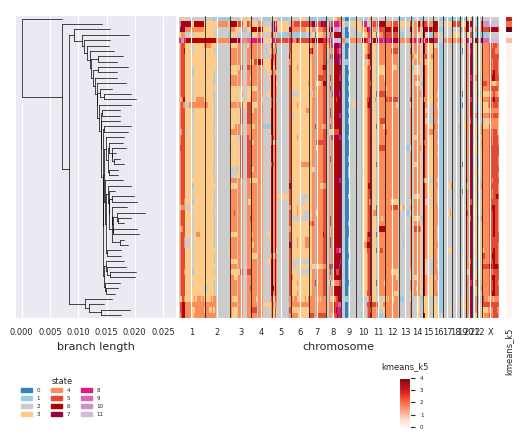

In [13]:
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='state', tree=bio_tree, annotation_fields=[clustering_lab])
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cellmates-cn', tree=bio_tree, annotation_fields=[clustering_lab])
# log-scale branches maybe

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


<bound method Figure.show of <Figure size 2400x1800 with 8 Axes>>

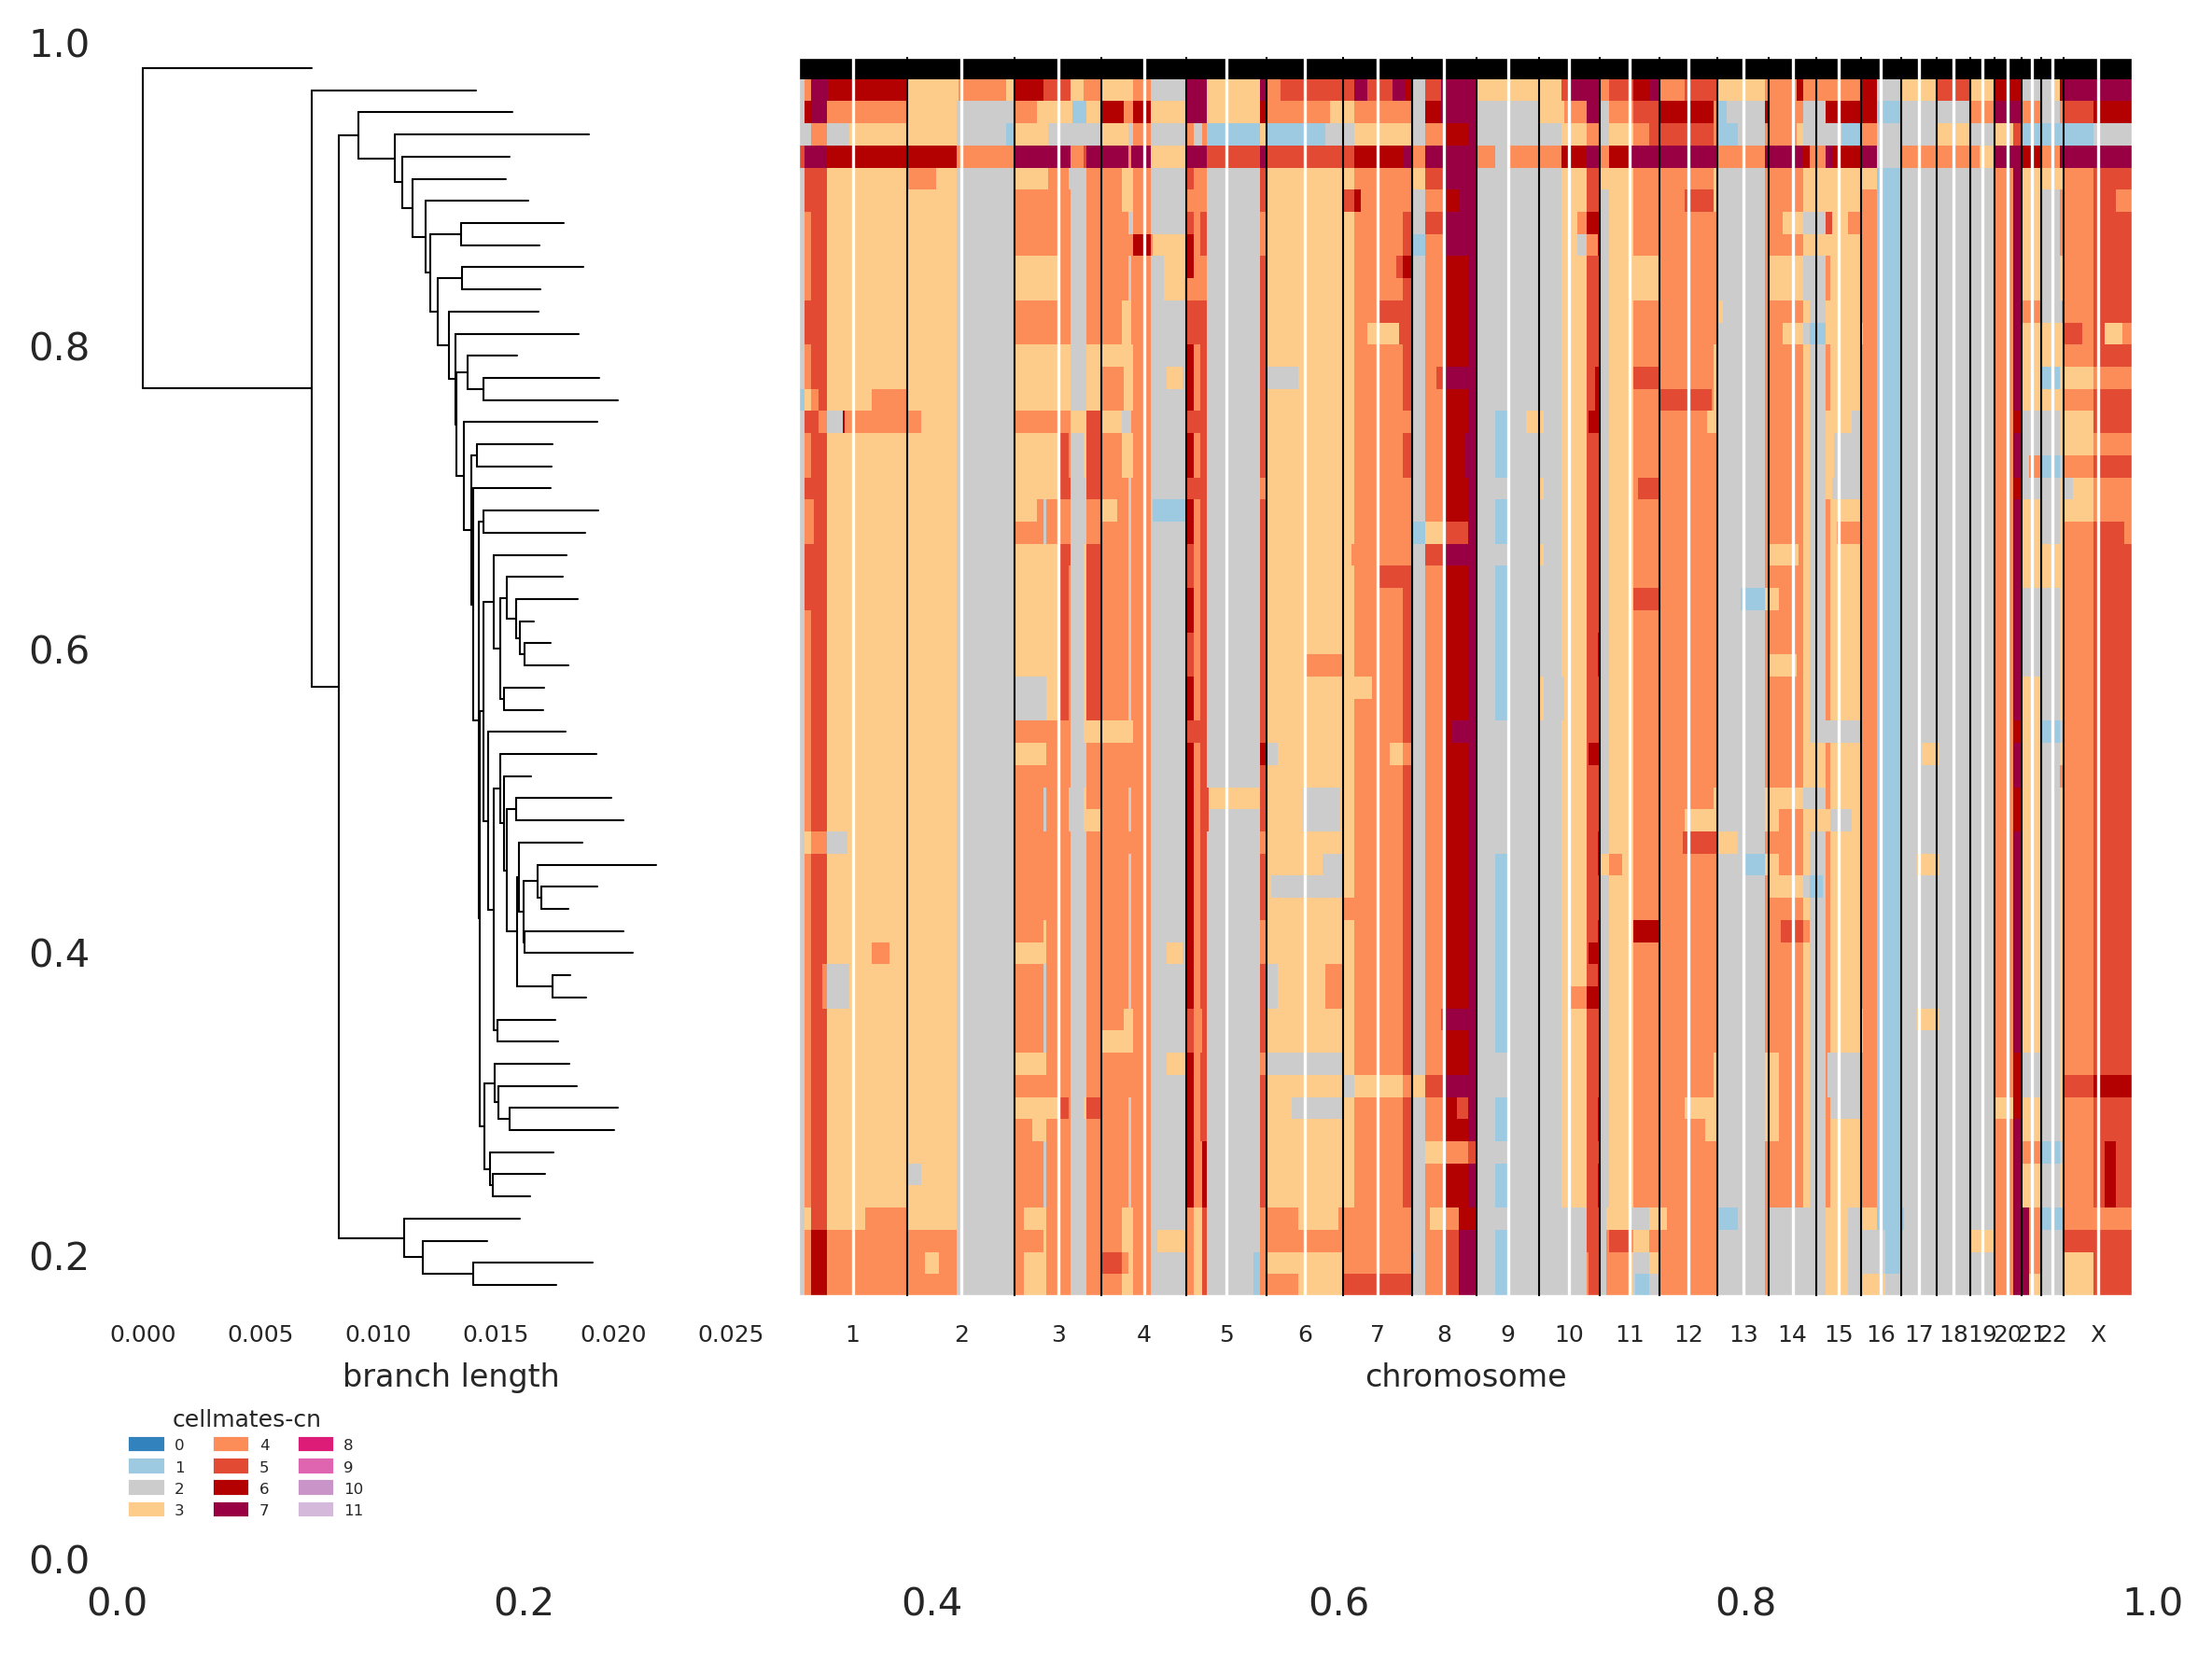

In [17]:
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='state', tree=bio_tree, annotation_fields=[clustering_lab, 'is_s_phase'])
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cellmates-cn', tree=bio_tree, annotation_fields=[clustering_lab])
fig, ax = plt.subplots(figsize=(8, 6), dpi=300, )
fig.tight_layout()
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cellmates-cn', tree=bio_tree, fig=fig
                               # annotation_fields=[clustering_lab]
                               )
# vmax = np.nanpercentile(adata[cell_names].layers['copy'], 98)
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='copy', tree=bio_tree, fig=fig, raw=True, vmax=vmax
#                                # annotation_fields=[clustering_lab]
#                                )
for a in fig.axes:
    a.set_facecolor('white')
    # a.set(xticks=[], yticks=[])

g['fig'].show
# log-scale branches maybe

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


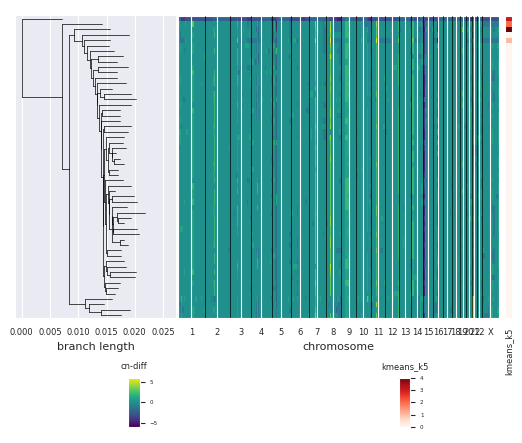

In [28]:
adata.layers['cn-diff'] = adata.layers['cellmates-cn'] - np.clip(adata.layers['state'], a_min=0, a_max=8)
# adata.layers['cn-reads-diff'] = adata.layers['cellmates-cn'] - np.clip(adata.layers['copy'], a_min=0, a_max=8)
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cn-diff', tree=bio_tree, annotation_fields=[clustering_lab], raw=True)
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cn-reads-diff', tree=bio_tree, annotation_fields=[clustering_lab], raw=True)

In [29]:
cm_cn_mad = np.nanmean(np.abs(adata.layers['cellmates-cn'] - adata.layers['state']))
# cm_cn_mad = np.nanmean(np.abs(adata.layers['cellmates-cn-jitter'] - adata.layers['state']))
print(f"CN MAD against original (HMMcopy) {cm_cn_mad}")

CN MAD against original (HMMcopy) 0.23680124223602483


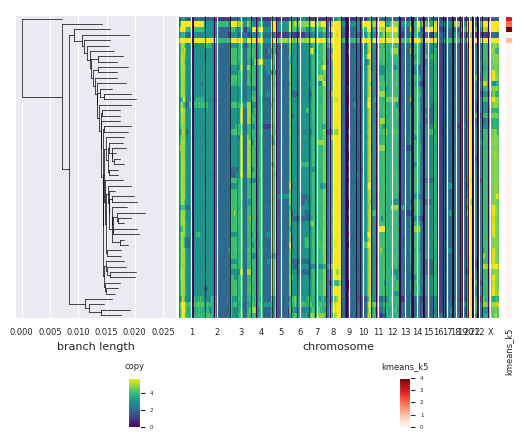

In [30]:
perc_98 = np.nanquantile(adata.layers['copy'], .95)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

In [31]:
nx_tree_int = relabel_name_to_int(nx_tree, cell_names)
dpy_tree = convert_networkx_to_dendropy(nx_tree_int, edge_length='weight')
f1_score = f1_score_clades(dpy_tree, adata[cell_names].obs[clustering_lab])

In [32]:
f1_score

0.22639321865787032

### MEDICC2

In [90]:
medicc_adata = anndata.read_h5ad(os.path.join(cm_out_dir, "medicc2", "MM03_medicc2_output.h5ad"))
medicc_adata_cells = medicc_adata[cell_names].copy()
medicc_adata_cells.obs[clustering_lab] = adata[medicc_adata_cells.obs_names].obs[clustering_lab]
medicc_adata_cells.layers['copy'] = adata[medicc_adata_cells.obs_names, medicc_adata_cells.var_names].layers['copy']
medicc_adata_cells

AnnData object with n_obs × n_vars = 105 × 5298
    obs: 'is_ancestor', 'branch_length', 'kmeans_k5'
    var: 'chrom', 'start', 'end'
    uns: 'medicc2_pairwise_distances', 'medicc2_summary', 'medicc2_tree_newick'
    layers: 'copy'

In [91]:
# add cn to adata
import pandas as pd
cn_df = pd.read_csv(os.path.join(cm_out_dir, "medicc2", "MM03_medicc2_input_final_final_cn_profiles.tsv"), delimiter='\t')
cn_tab = cn_df.pivot(index='sample_id', columns=['chrom', 'start', 'end'], values='total_cn')
assert np.all([c in cn_tab.index for c in cell_names])
medicc_adata_cells.layers['medicc2-cn'] = cn_tab.loc[cell_names]


In [92]:
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chrom']
#manipulate chr
chr_codes = {c: c[3:] for c in medicc_adata_cells.var['chr'].unique()}
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chr'].map(chr_codes)

In [93]:
# CONVERT MEDICC TREE TO BIO TREE
# need to re-root so to include only the tumor cells
# internal_7 was found by printing the successors of 'diploid' ancestor (that is 'None')
med_tree_nwk = medicc_adata_cells.uns['medicc2_tree_newick']
med_nx_tree = newick_to_nx(med_tree_nwk)
edges = [(u, v, med_nx_tree.edges[u,v]['weight']) for (u, v) in nx.dfs_tree(med_nx_tree, 'internal_7').edges]
med_nx_tree = nx.DiGraph()
med_nx_tree.add_weighted_edges_from(edges)
# print([(n, nx.ancestors(med_nx_tree, n)) for n in med_nx_tree.nodes if (med_nx_tree.out_degree(n) == 0 and n not in cell_names)])
# print(list(med_nx_tree.successors('None')))
med_bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(med_nx_tree, weight='weight')), format="newick")
med_nx_tree = relabel_name_to_int(med_nx_tree, cell_names)
med_dpy_tree = convert_networkx_to_dendropy(med_nx_tree, edge_length='weight', taxon_namespace=dpy_tree.taxon_namespace)
med_f1_score = f1_score_clades(med_dpy_tree, medicc_adata_cells.obs[clustering_lab])

In [94]:
med_f1_score

0.6591800356506238

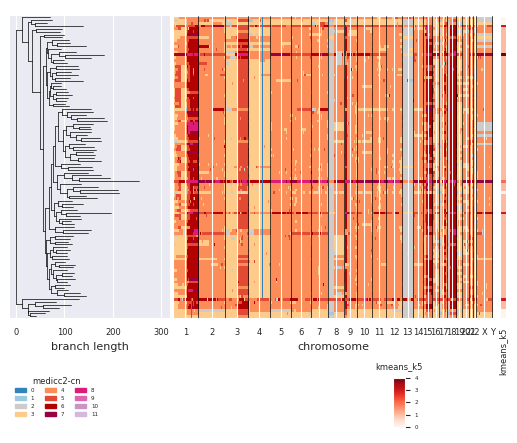

In [95]:
# g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name=None, tree=med_bio_tree, annotation_fields=[clustering_lab])
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='medicc2-cn', tree=med_bio_tree, annotation_fields=[clustering_lab])


### MEDICC2 tree on cellmates copy number profile

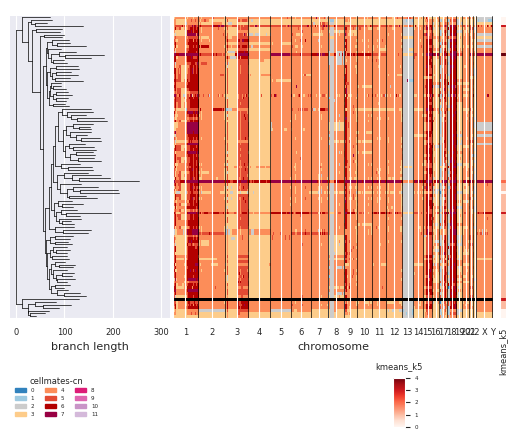

In [96]:
# plot cellmates cn onto medicc tree
medicc_adata_cells.layers['cellmates-cn'] = adata[cell_names, medicc_adata_cells.var_names].layers['cellmates-cn']
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='cellmates-cn', tree=med_bio_tree, annotation_fields=[clustering_lab])


In [97]:
med_cn_mad = np.nanmean(np.abs(medicc_adata_cells[cell_names, adata.var_names].layers['medicc2-cn'] - adata[cell_names].layers['state']))
print(f"MEDICC2 CN MAD against original (HMMcopy) {med_cn_mad} - cellmates CN MAD agains original: {cm_cn_mad}")
print(f"MEDICC2 CN MAD against cellmates: {np.nanmean(np.abs(medicc_adata_cells[cell_names, adata.var_names].layers['medicc2-cn'] - adata[cell_names].layers['cellmates-cn']))}")

MEDICC2 CN MAD against original (HMMcopy) 0.003940799789727997 - cellmates CN MAD agains original: 0.18787839509173296
MEDICC2 CN MAD against cellmates: 0.18802962483596686


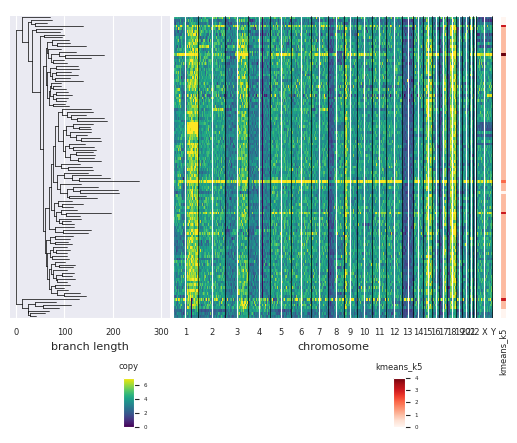

In [98]:
perc_98 = np.nanquantile(medicc_adata_cells.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='copy', tree=med_bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

In [99]:
# compare trees with RF
normalized_rf_distance(dpy_tree, med_dpy_tree)

0.970873786407767

## Analyse branch lengths

In [41]:
from cellmates.utils.math_utils import compute_cn_changes
import seaborn as sns
from scipy.stats import pearsonr

def get_cells_branch_lengths(tree_nwk, cell_names):
    # traverse the tree and sum lengths over branches
    nx_tree = newick_to_nx(tree_nwk)
    root = [n for n,d in nx_tree.in_degree() if d==0][0]
    cell_lengths = []
    for c in cell_names:
        cell_lengths.append(nx.shortest_path_length(nx_tree, root, c, weight='weight'))

    return cell_lengths

def get_cells_cn_changes(cn_mat, cell_names, root_ploidy = 2):
    cell_cn_changes = []
    root_cn = np.zeros_like(cn_mat[0]) + root_ploidy
    for c in range(len(cell_names)):
        cell_cn_changes.append(compute_cn_changes(np.vstack((root_cn, cn_mat[c])))[0])
    return cell_cn_changes

def plot_xy(x, y, remove_outliers=False, x_cutoff=None):
    if x_cutoff is not None:
        x_new = []
        y_new = []
        for i, val in enumerate(x):
            if val < x_cutoff:
                x_new.append(val)
                y_new.append(y[i])
        x = x_new
        y = y_new

    corr, pval = pearsonr(x, y)
    print('pearson correlation:', corr)
    print('p-value:', pval)

    # Create plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6, 's':50}, line_kws={'color':'red'})

    # Add correlation text
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {pval:.3e}',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel('X values')
    plt.ylabel('Y values')

    # Set axes limits if outliers
    if remove_outliers:
        # Calculate percentiles to exclude outliers
        x_lower, x_upper = np.percentile(x, [2.5, 97.5])
        y_lower, y_upper = np.percentile(y, [2.5, 97.5])

        plt.xlim(x_lower, x_upper)
        plt.ylim(y_lower, y_upper)

    plt.title('Scatter Plot with Regression Line')
    plt.tight_layout()
    plt.show()

### Cellmates
Current analysis uses inference from CN data (fair comparison)

In [42]:
from math import log

cm_bl = get_cells_branch_lengths(tree_nwk, cell_names)
cm_cc = get_cells_cn_changes(adata.layers['cellmates-cn'], cell_names) # CELLMATES CN 0.79 correlation
# cm_cc = get_cells_cn_changes(medicc_adata_cells.layers['medicc2-cn'], cell_names)  # MEDICC CN 0.51
# cm_cc = get_cells_cn_changes(adata.layers['state'], cell_names) # HMMCopy 0.58
# log version
# cm_bl = [log(l+1) for l in cm_bl]  # 0.20 correlation


pearson correlation: 0.8551242199392698
p-value: 1.0248921177096426e-29


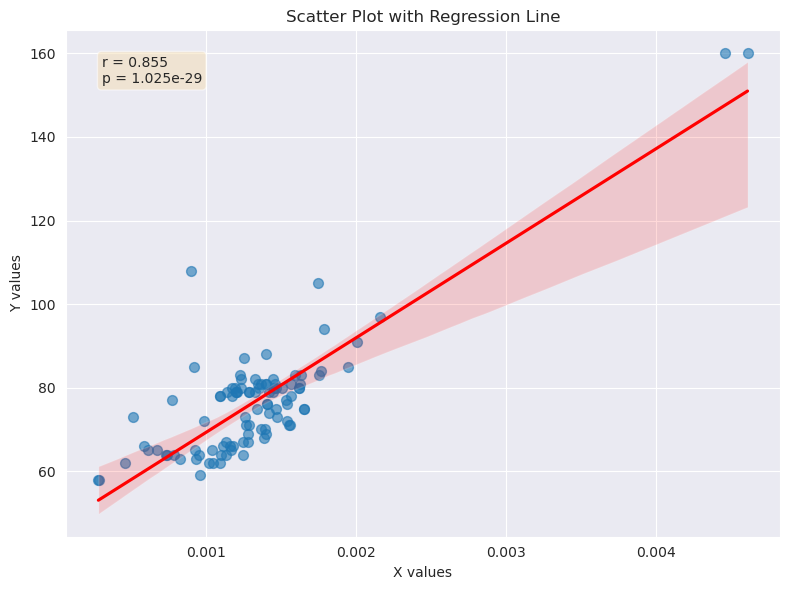

In [43]:
plot_xy(cm_bl, cm_cc)
# plot_xy(cm_bl, cm_cc, x_cutoff=log(1.025))

### MEDICC2

In [103]:
# for each cell
med_bl = get_cells_branch_lengths(med_tree_nwk, cell_names)
med_cc = get_cells_cn_changes(medicc_adata_cells.layers['medicc2-cn'], cell_names)  # MEDICC CN 0.83 pearson correlation
# med_cc = get_cells_cn_changes(adata.layers['cellmates-cn'], cell_names)  # CELLMATES CN 0.44
# med_cc = get_cells_cn_changes(adata.layers['state'], cell_names)  # HMMCopy 0.68



pearson correlation: 0.8346000530627293
p-value: 1.9868201838570064e-28


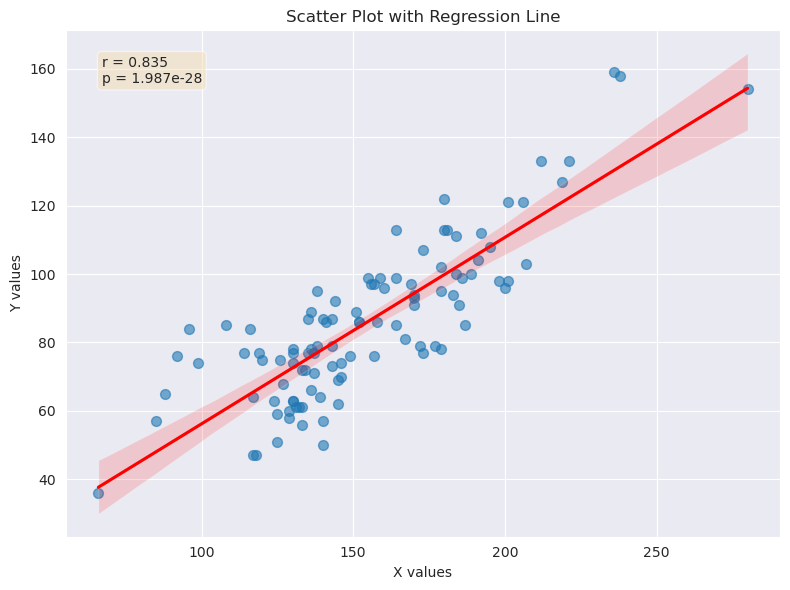

In [104]:
plot_xy(med_bl, med_cc)

## The birthday problem
With many cells it is more likely that two unrelated cells share the same breakpoint. For each breakpoint detected in cellmates, we count the number of cells that exhibit that breakpoint
Cellmates shows less cells that carry unique breakpoints. However from cellmates cn plot it seems that CN breakpoints easily happen multiple times (back and forth) on the same bin.

In [48]:
def cells_per_bkpt_shared_hist_single(cn_mat, title='Count of cells that share the same breakpoint', include_zero_count: bool = False):
    bkpt = np.diff(cn_mat, axis=1)
    # number of cells sharing the same breakpoint (for every breakpoint)
    binwidth = 1
    cells_per_bkpt = np.sum(bkpt != 0, axis=0)
    xstart = 0
    if not include_zero_count:
        xstart = 1
        cells_per_bkpt = cells_per_bkpt[cells_per_bkpt > 0]
    hist_dat = plt.hist(cells_per_bkpt, bins=range(xstart, max(cells_per_bkpt) + binwidth, binwidth))
    plt.xlim(xstart,20)
    plt.xticks(np.arange(xstart, 21, 1))
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    return hist_dat

def cells_per_bkpt_shared_hist(
    cn_mat,
    title='Count of cells that share the same breakpoint',
    include_zero_count: bool = False,
    labels=None,
    colors=None,
    figsize=(10, 6),
    style='whitegrid'
):
    """
    Plot histogram of cells sharing breakpoints with Seaborn styling.

    Parameters:
    -----------
    cn_mat : np.ndarray or list of np.ndarray
        Copy number matrix or list of matrices to plot
    title : str
        Plot title
    include_zero_count : bool
        Whether to include breakpoints with zero cells
    labels : list of str, optional
        Labels for each matrix (when passing list of matrices)
    colors : list of str, optional
        Colors for each histogram (when passing list of matrices)
    figsize : tuple
        Figure size (width, height)
    style : str
        Seaborn style ('whitegrid', 'darkgrid', 'white', 'dark', 'ticks')

    Returns:
    --------
    dict : Dictionary containing histogram data for each matrix
    """
    # Set seaborn style
    sns.set_style(style)

    # Handle single matrix or list of matrices
    if cn_mat.ndim == 3:
        cn_mat = [cn_mat[i] for i in range(cn_mat.shape[0])]

    if labels is None:
        labels = [f'Matrix {i+1}' for i in range(len(cn_mat))]

    if colors is None:
        colors = sns.color_palette('husl', len(cn_mat))

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    hist_data = {}
    all_cells_per_bkpt = []

    # Process each matrix
    for idx, mat in enumerate(cn_mat):
        bkpt = np.diff(mat, axis=1)
        cells_per_bkpt = np.sum(bkpt != 0, axis=0)

        xstart = 0 if include_zero_count else 1
        if not include_zero_count:
            cells_per_bkpt = cells_per_bkpt[cells_per_bkpt > 0]

        all_cells_per_bkpt.append(cells_per_bkpt)

        # Plot histogram with seaborn
        sns.histplot(
            cells_per_bkpt,
            bins=range(xstart, max(cells_per_bkpt) + 2),
            alpha=0.6,
            color=colors[idx],
            label=labels[idx],
            kde=False,
            ax=ax,
            stat='count'
        )

        hist_data[labels[idx]] = cells_per_bkpt

    # Styling
    ax.set_xlim(xstart if include_zero_count else 1, 20)
    ax.set_xticks(np.arange(xstart if include_zero_count else 1, 21, 1))
    ax.set_xlabel('Number of cells sharing breakpoint', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    if len(cn_mat) > 1:
        ax.legend(frameon=True, shadow=True, fontsize=10)

    # Add grid for better readability
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return hist_data


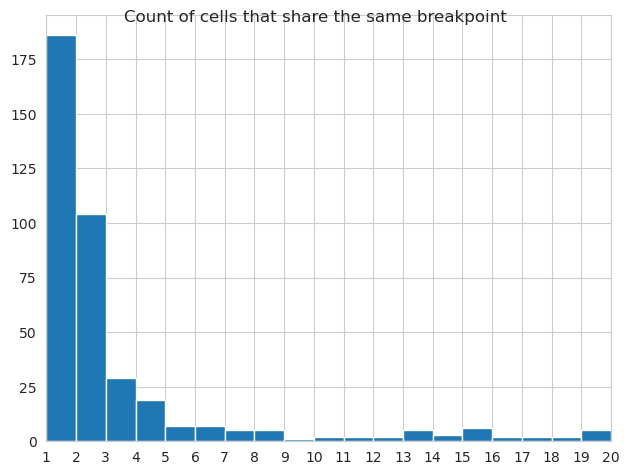

(array([186., 104.,  29.,  19.,   7.,   7.,   5.,   5.,   1.,   2.,   2.,
          2.,   5.,   3.,   6.,   2.,   2.,   2.,   5.,   0.,   2.,   1.,
          1.,   0.,   1.,   2.,   2.,   0.,   1.,   2.,   0.,   1.,   0.,
          1.,   0.,   0.,   1.,   1.,   0.,   2.,   2.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.,   1.,   1.,   0.,   0.,   0.,
          1.,   2.,   1.,   2.,   2.,   1.,   0.,   2.,   2.,   0.,   3.,
          0.,   0.,   3.,   1.,   1.,   2.,   2.,   0.,   1.,   0.,   1.,
          1.,   1.,   0.,   1.,   1.,   2.,   1.,   2.,   1.,   3.,   1.,
          1.,   2.,   1.,   0.,   2.,   3.,   1.,   4.,   1.,   5.,   8.]),
 array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
         23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
         34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
         45.,  46.,  47.,  48.,  49.

In [50]:
# cells_per_bkpt_shared_hist(adata.layers['cellmates-cn'], labels=['cellmates'], title='Count of cells that share the same breakpoint', include_zero_count=True)
cells_per_bkpt_shared_hist_single(adata.layers['cellmates-cn'], title='Count of cells that share the same breakpoint', include_zero_count=False)

<Axes: title={'center': 'Copy number profile'}, xlabel='bins', ylabel='cells'>

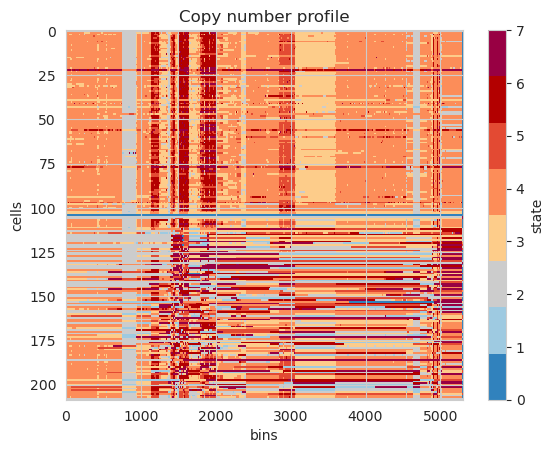

In [147]:
from cellmates.utils.visual import plot_cn_profile
full_cn_pred = np.load(os.path.join(cm_out_dir, 'predicted_copy_numbers.npz'))
plot_cn_profile(full_cn_pred['data'])